Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


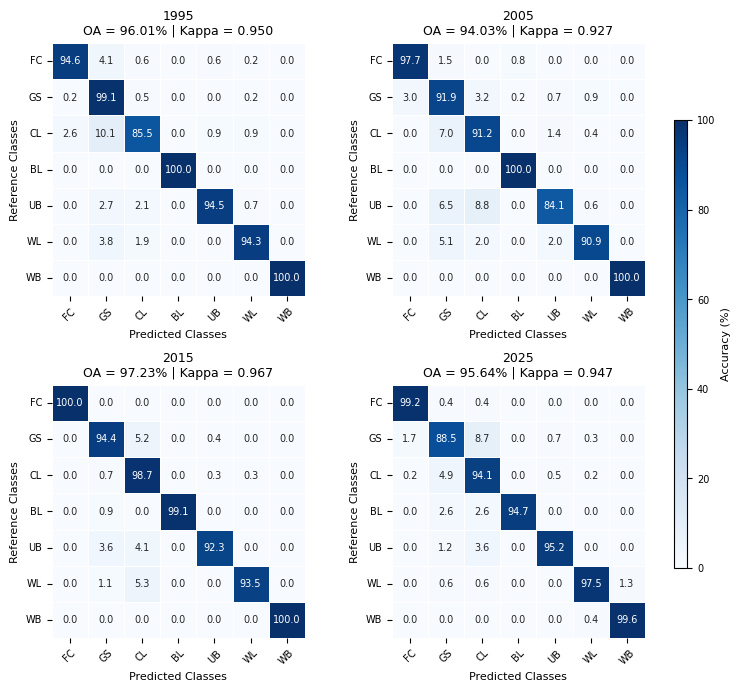

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, cohen_kappa_score

folder_path = '/content/drive/My Drive/tanganyikabasinbdi/'

years = [1995, 2005, 2015, 2025]

class_names = ["FC", "GS", "CL", "BL", "UB", "WL", "WB"]

target_width_pixels = 2244
dpi = 300

fig_width = target_width_pixels / dpi
fig_height = 7.0

fig, axes = plt.subplots(
    2, 2,
    figsize=(fig_width, fig_height),
    constrained_layout=False
)

axes = axes.flatten()

vmin = 0
vmax = 100

summary_metrics = []

for i, year in enumerate(years):

    file_path = os.path.join(
        folder_path,
        f'{year}_validation_points.csv'
    )

    df = pd.read_csv(file_path)

    y_true = df['classValue']
    y_pred = df['classification']

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=range(7)
    )

    cm_table = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_table.to_csv(
        f'/content/{year}_raw_confusion_matrix.csv'
    )

    oa = np.trace(cm) / np.sum(cm)

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    user_acc = cm.diagonal() / cm.sum(axis=1)

    prod_acc = cm.diagonal() / cm.sum(axis=0)

    f1 = 2 * (
        user_acc * prod_acc
    ) / (
        user_acc + prod_acc
    )

    metrics_table = pd.DataFrame({
        'Land_Cover_Class': class_names,
        'Users_Accuracy': np.round(user_acc * 100, 2),
        'Producers_Accuracy': np.round(prod_acc * 100, 2),
        'F1_Score': np.round(f1 * 100, 2)
    })

    metrics_table.to_csv(
        f'/content/{year}_accuracy_metrics.csv',
        index=False
    )

    summary_metrics.append({
        'Year': year,
        'Overall_Accuracy': round(oa * 100, 2),
        'Kappa_Coefficient': round(kappa, 4)
    })

    cm_norm = (
        cm.astype('float') /
        cm.sum(axis=1)[:, np.newaxis]
    ) * 100

    ax = axes[i]

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        vmin=vmin,
        vmax=vmax,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        linewidths=0.4,
        linecolor='white',
        annot_kws={"size": 7},
        ax=ax
    )

    ax.set_title(
        f'{year}\nOA = {oa*100:.2f}% | Kappa = {kappa:.3f}',
        fontsize=9,
        pad=6
    )

    ax.set_xlabel(
        'Predicted Classes',
        fontsize=8
    )

    ax.set_ylabel(
        'Reference Classes',
        fontsize=8
    )

    ax.tick_params(
        axis='x',
        labelrotation=45,
        labelsize=7
    )

    ax.tick_params(
        axis='y',
        rotation=0,
        labelsize=7
    )

cbar_ax = fig.add_axes([
    0.92,
    0.18,
    0.018,
    0.64
])

norm = plt.Normalize(
    vmin=vmin,
    vmax=vmax
)

sm = plt.cm.ScalarMappable(
    cmap='Blues',
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax
)

cbar.set_label(
    'Accuracy (%)',
    fontsize=8
)

cbar.ax.tick_params(
    labelsize=7
)

plt.subplots_adjust(
    left=0.08,
    right=0.89,
    top=0.93,
    bottom=0.08,
    wspace=0.28,
    hspace=0.35
)

plt.savefig(
    '/content/Confusion_Matrices.png',
    dpi=dpi,
    bbox_inches='tight'
)

plt.show()

summary_df = pd.DataFrame(summary_metrics)

summary_df.to_csv(
    '/content/Overall_Accuracy_Summary.csv',
    index=False
)